# Importing Library

## Pip install thing (just to shorten the installation log)

In [1]:
# !pip install --user tensorflow==2.17
# !pip install --user opencv-python
# !pip install --user matplotlib
# !pip install --user tensorflow-hub
# !pip install --user scikit-learn
# !pip install --user numpy==1.26.4 
# !pip install --user seaborn

## Importing Library

### Run this if you're on Jupyter Lab

In [30]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import seaborn as sns
import glob
import cv2
import zipfile
from tensorflow.keras import layers, models, Model, Input, regularizers
from tensorflow.keras.applications import InceptionResNetV2, Xception
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential  # Sequential API for building models layer by layer
from tensorflow.keras.utils import to_categorical
import shutil
from PIL import Image
import hashlib
import random
from pathlib import Path
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

print("TF version:", tf.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")
# Check for GPU availability in TensorFlow
device = "GPU" if len(tf.config.list_physical_devices('GPU')) > 0 else "CPU"
print("The device is:", device)

# rm -rf '/content/__MACOSX'
# use this one when you need to remove folder and not getting must be empty error

TF version: 2.19.0
GPU is NOT AVAILABLE
The device is: CPU


# Extracting Data

### Loading and Unzipping Data From Drive

In [3]:
# Define the extraction paths
train_extract_path = 'dataset/train_images/'
test_extract_path = 'dataset/test_images/'

# For train images: remove if exists, then extract
if os.path.exists(train_extract_path):
    print(f"Removing existing train images folder: {train_extract_path}")
    shutil.rmtree(train_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(train_extract_path, exist_ok=True)

# Extract train images
with zipfile.ZipFile('zip_data/train_images.zip', 'r') as train_zip_ref:
    print("Extracting train images...")
    train_zip_ref.extractall(train_extract_path)
    print("Train images extracted successfully.")

# For test images: remove if exists, then extract
if os.path.exists(test_extract_path):
    print(f"Removing existing test images folder: {test_extract_path}")
    shutil.rmtree(test_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(test_extract_path, exist_ok=True)

# Extract test images
with zipfile.ZipFile('zip_data/test_images.zip', 'r') as test_zip_ref:
    print("Extracting test images...")
    test_zip_ref.extractall(test_extract_path)
    print("Test images extracted successfully.")

print("All extraction complete!")

Removing existing train images folder: dataset/train_images/
Extracting train images...
Train images extracted successfully.
Removing existing test images folder: dataset/test_images/
Extracting test images...
Test images extracted successfully.
All extraction complete!


### Check Class Names

In [4]:
CLASS_NAMES = [os.path.basename(l) for l in glob.glob('dataset/train_images/train_images/*')
               if '.' not in l]
# CLASS_NAMES = [os.path.basename(l) for l in glob.glob('/content/drive/MyDrive/Colab Notebooks/train_images/train_images/*')
#                if '.' not in l]  ## if on google colab
print(CLASS_NAMES)

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


### Load CSV file

In [5]:
# train_df = pd.read_csv('/content/drive/MyDrive/Dataset/meta_train.csv')
train_df = pd.read_csv('opencv/meta_train.csv')
train_df

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45
...,...,...,...,...
10402,107607.jpg,tungro,Zonal,55
10403,107811.jpg,tungro,Zonal,55
10404,108547.jpg,tungro,Zonal,55
10405,110245.jpg,tungro,Zonal,55


Map the path depending on the label first

In [6]:
# train_df['path'] = '/content/drive/MyDrive/Colab Notebooks/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df['path'] = 'dataset/train_images/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...


# Data Loading and Preprocessing

### Check Duplicates in dataset

In [7]:
def calculate_hash(image_path):
    with Image.open(image_path) as img:
        return hashlib.md5(img.tobytes()).hexdigest()

def find_duplicates_in_dataset(root_folder):
    hashes = {}
    duplicates = []

    for subdir, _, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg')):
                path = os.path.join(subdir, file)
                try:
                    file_hash = calculate_hash(path)
                    if file_hash in hashes:
                        duplicates.append((path, hashes[file_hash]))
                    else:
                        hashes[file_hash] = path
                except Exception as e:
                    print(f"Error processing {file}: {e}")
    
    return duplicates
    
# Function to delete duplicate files, keeping only the first occurrence
def remove_duplicate_files(duplicates):
    removed_count = 0
    for duplicate_path, original_path in duplicates:
        try:
            # Check if file exists before attempting to remove
            if os.path.exists(duplicate_path):
                os.remove(duplicate_path)
                print(f"Removed: {duplicate_path}")
                removed_count += 1
            else:
                print(f"File not found: {duplicate_path}")
        except Exception as e:
            print(f"Error removing {duplicate_path}: {e}")
    
    return removed_count

duplicates = find_duplicates_in_dataset('dataset/train_images/train_images/')
for dup1, dup2 in duplicates:
    print(f"Duplicate found:\n -> {dup1}\n -> {dup2}\n")

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\100513.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100169.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\103032.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100133.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\104800.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\102353.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\105878.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\103344.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\106984.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100998.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\107812.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100635.jpg

Duplicate found:
 -> dataset/train_image

Then we will remove these dulpicate ones from the dataframe
Then we need to remove it from the dataset as well.

In [8]:
# Remove the duplicate files from the filesystem
if duplicates:
    removed_count = remove_duplicate_files(duplicates)
    print(f"\nRemoved {removed_count} duplicate image files")
else:
    print("No duplicates found.")

# If you also need to update your dataframe after removing files
if 'train_df' in locals() or 'train_df' in globals():
    # Extract ONLY the duplicate paths (not the originals) to remove from dataframe
    paths_to_remove = [duplicate_path for duplicate_path, original_path in duplicates]
    
    # Normalize paths to ensure consistent comparison
    train_df['path'] = train_df['path'].apply(os.path.normpath)
    paths_to_remove = [os.path.normpath(path) for path in paths_to_remove]
    
    # Remove only the duplicate entries from dataframe
    original_length = len(train_df)
    train_df = train_df[~train_df['path'].isin(paths_to_remove)].reset_index(drop=True)
    removed_count = original_length - len(train_df)
    
    print(f"Removed {removed_count} duplicate image entries from dataframe")

Removed: dataset/train_images/train_images/bacterial_leaf_blight\100513.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\103032.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\104800.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\105878.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\106984.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\107812.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\108125.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\108353.jpg
Removed: dataset/train_images/train_images/bacterial_panicle_blight\104803.jpg
Removed: dataset/train_images/train_images/blast\102705.jpg
Removed: dataset/train_images/train_images/blast\105626.jpg
Removed: dataset/train_images/train_images/blast\105840.jpg
Removed: dataset/train_images/train_images/blast\105962.jpg
Removed: dataset/train_images/train_images/blast\106520.jpg
Removed: data

### Sorted into folder according to their variety

In [9]:
# Define output base directory
output_base_dir = "dataset/train_images_by_exact_age"

# Reset output directory
if os.path.exists(output_base_dir):
    shutil.rmtree(output_base_dir)
    print(f"Removed existing directory: {output_base_dir}")

os.makedirs(output_base_dir, exist_ok=True)

# Get unique ages
ages = train_df["age"].unique()
print(f"Found {len(ages)} unique ages: {sorted(ages)}")

# Create directories for each age
for age in ages:
    age_dir = os.path.join(output_base_dir, f"{age}")
    os.makedirs(age_dir, exist_ok=True)

# Copy files to their new locations
print("Copying images to age folders...")
for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
    src_path = row["path"]
    dst_path = os.path.join(output_base_dir, f"{row['age']}", row['image_id'])

    try:
        shutil.copy2(src_path, dst_path)
    except FileNotFoundError:
        print(f"Warning: Could not find {src_path}")

print("Done. Images have been sorted into directories by exact age.")
print(f"New directory structure: {output_base_dir}/age/[image_id]")

# Count files in each age directory to verify
for age in ages:
    age_dir = os.path.join(output_base_dir, f"{age}")
    file_count = len([f for f in os.listdir(age_dir) if os.path.isfile(os.path.join(age_dir, f))])
    print(f"Age {age}: {file_count} images")


Removed existing directory: dataset/train_images_by_exact_age
Found 18 unique ages: [45, 47, 50, 55, 57, 60, 62, 65, 66, 67, 68, 70, 72, 73, 75, 77, 80, 82]
Copying images to age folders...


100%|███████████████████████████████████████████████████████████████████████████| 10333/10333 [00:13<00:00, 748.63it/s]


Done. Images have been sorted into directories by exact age.
New directory structure: dataset/train_images_by_exact_age/age/[image_id]
Age 45: 503 images
Age 50: 1054 images
Age 55: 560 images
Age 60: 1650 images
Age 65: 768 images
Age 68: 253 images
Age 70: 3059 images
Age 72: 543 images
Age 47: 112 images
Age 77: 42 images
Age 67: 411 images
Age 73: 38 images
Age 75: 857 images
Age 80: 225 images
Age 62: 5 images
Age 66: 36 images
Age 57: 212 images
Age 82: 5 images


I see there's 2 minor class with only 5 images, which is at day age 62 and day age 82, so we will remove them.

### Map the csv depending on the age

In [10]:
train_df = train_df.drop('path', axis=1)
train_df['path'] = 'dataset/train_images_by_exact_age/' + train_df['age'].astype(str) + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/101918.jpg


In [11]:
train_df

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/101918.jpg
...,...,...,...,...,...
10328,107607.jpg,tungro,Zonal,55,dataset/train_images_by_exact_age/55/107607.jpg
10329,107811.jpg,tungro,Zonal,55,dataset/train_images_by_exact_age/55/107811.jpg
10330,108547.jpg,tungro,Zonal,55,dataset/train_images_by_exact_age/55/108547.jpg
10331,110245.jpg,tungro,Zonal,55,dataset/train_images_by_exact_age/55/110245.jpg


### Minor Class Removal

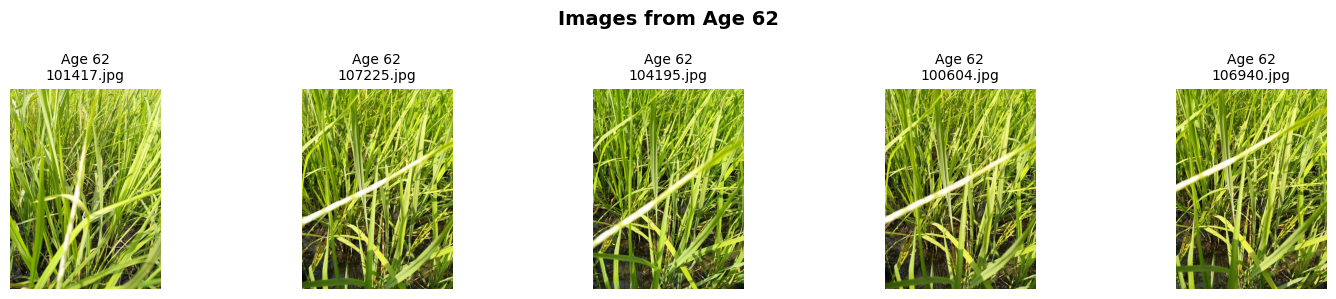

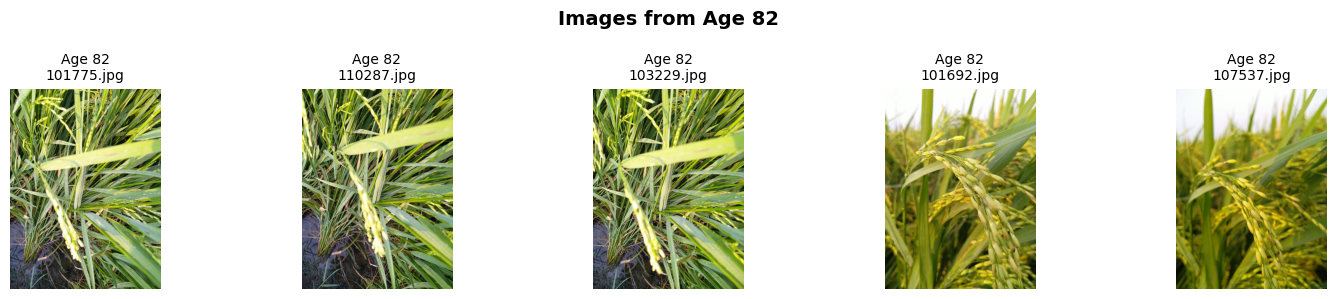

In [12]:
def show_minor_images(train_df, ages_to_show=[62, 82], images_per_age=5):
    for age in ages_to_show:
        age_df = train_df[train_df['age'] == age]
        sample_df = age_df.sample(min(images_per_age, len(age_df)), random_state=42)
        
        plt.figure(figsize=(15, 3))
        for i, row in enumerate(sample_df.itertuples()):
            img = Image.open(row.path)
            plt.subplot(1, images_per_age, i+1)
            plt.imshow(img)
            plt.title(f"Age {age}\n{row.image_id}", fontsize=10)
            plt.axis('off')
        
        plt.suptitle(f"Images from Age {age}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

show_minor_images(train_df, ages_to_show=[62, 82], images_per_age=5)

Most of the images of class age 62 and age 82 given in this dataset is duplicate anyway, thats why I will remove them out of the dataset.

In [13]:
# Remove age 62 and 82 from the DataFrame
ages_to_remove = [62, 82]
train_df = train_df[~train_df['age'].isin(ages_to_remove)].reset_index(drop=True)

print("Updated DataFrame shape:", train_df.shape)

Updated DataFrame shape: (10323, 5)


In [14]:
# Loop over removed ages and delete their images
for age in ages_to_remove:
    age_folder = os.path.join('dataset/train_images_by_exact_age', str(age))
    if os.path.exists(age_folder):
        for img_file in os.listdir(age_folder):
            img_path = os.path.join(age_folder, img_file)
            try:
                os.remove(img_path)
            except Exception as e:
                print(f"Could not delete {img_path}: {e}")
        # Optional: Remove the now-empty folder
        try:
            os.rmdir(age_folder)
        except OSError:
            print(f"Folder not empty or could not remove: {age_folder}")
    else:
        print(f"Age folder not found: {age_folder}")

### Data Distribution

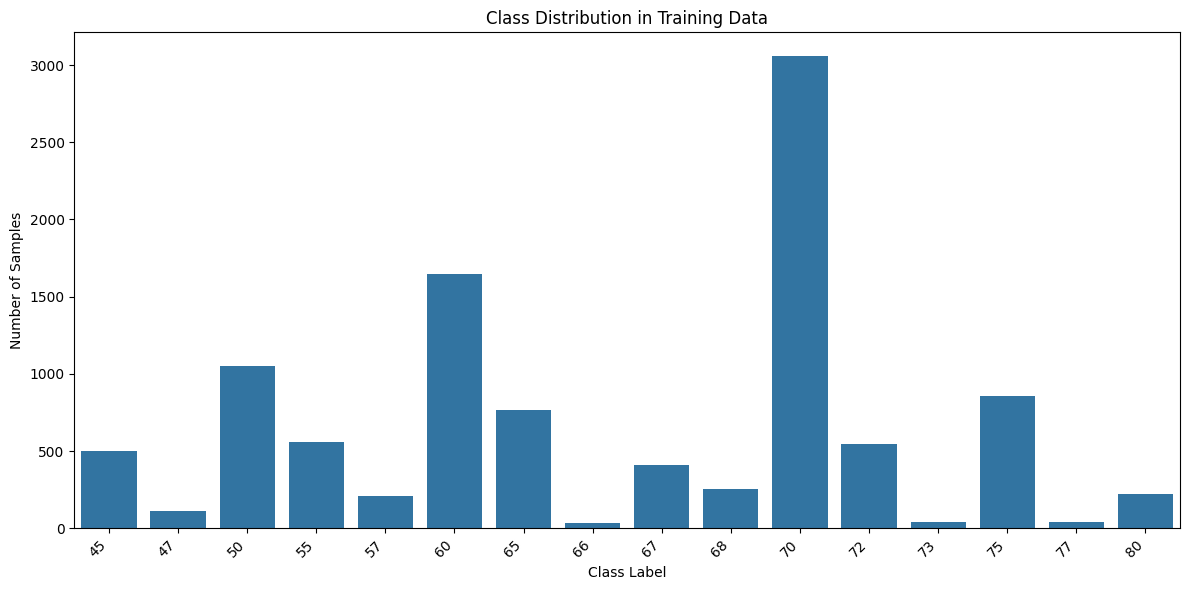

Class distribution:
70: 3059 samples (29.63%)
60: 1650 samples (15.98%)
50: 1054 samples (10.21%)
75: 857 samples (8.30%)
65: 768 samples (7.44%)
55: 560 samples (5.42%)
72: 543 samples (5.26%)
45: 503 samples (4.87%)
67: 411 samples (3.98%)
68: 253 samples (2.45%)
80: 225 samples (2.18%)
57: 212 samples (2.05%)
47: 112 samples (1.08%)
77: 42 samples (0.41%)
73: 38 samples (0.37%)
66: 36 samples (0.35%)


In [15]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
class_counts = train_df['age'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the exact counts
print("Class distribution:")
for age, count in class_counts.items():
    print(f"{age}: {count} samples ({count/len(train_df)*100:.2f}%)")

Add function to check the total count of image dataset

In [16]:
train_data_path = 'dataset/train_images_by_exact_age'

def check_total_images(data_dir):
    """
    Prints the number of images per class and the total in the dataset directory.
    """
    total = 0
    print("Image Count Per Class:")
    print("-" * 30)
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        total += count
        print(f"{class_name:25}: {count} images")
    print("-" * 30)
    print(f"Total images in dataset: {total}")

check_total_images(train_data_path)

Image Count Per Class:
------------------------------
45                       : 503 images
47                       : 112 images
50                       : 1054 images
55                       : 560 images
57                       : 212 images
60                       : 1650 images
65                       : 768 images
66                       : 36 images
67                       : 411 images
68                       : 253 images
70                       : 3059 images
72                       : 543 images
73                       : 38 images
75                       : 857 images
77                       : 42 images
80                       : 225 images
------------------------------
Total images in dataset: 10323


## Augmentating the Data before Splitting and Loading

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

train_data_path = 'dataset/train_images_by_exact_age'

# Step 1: Count images per class
class_counts = {}
for class_name in os.listdir(train_data_path):
    class_path = os.path.join(train_data_path, class_name)
    if not os.path.isdir(class_path): continue
    image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    class_counts[class_name] = len(image_files)

# Step 2: Define augmentation
augmentor = ImageDataGenerator(
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,
    fill_mode='nearest'
)

average_count = int(np.mean(list(class_counts.values())))
print(f"Target image count per class: {average_count}")

# Step 3: Augment classes below the average
for class_name, count in class_counts.items():
    if count >= average_count:
        print(f"Skipping '{class_name}' (already has {count} images)")
        continue

    class_path = os.path.join(train_data_path, class_name)
    images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    current_count = count
    augment_index = 0

    print(f"Augmenting '{class_name}' from {current_count} to {average_count}")
    pbar = tqdm(total=average_count - current_count)

    while current_count < average_count:
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = load_img(img_path)
            x = img_to_array(img).reshape((1,) + img_to_array(img).shape)

            batch = next(augmentor.flow(x, batch_size=1))
            new_img = array_to_img(batch[0])
            new_img.save(os.path.join(class_path, f'aug_{augment_index}.jpg'))

            current_count += 1
            augment_index += 1
            pbar.update(1)

            if current_count >= average_count:
                break

    pbar.close()


Target image count per class: 645
Augmenting '45' from 503 to 645


100%|████████████████████████████████████████████████████████████████████████████████| 142/142 [00:14<00:00,  9.91it/s]


Augmenting '47' from 112 to 645


100%|████████████████████████████████████████████████████████████████████████████████| 533/533 [00:47<00:00, 11.29it/s]


Skipping '50' (already has 1054 images)
Augmenting '55' from 560 to 645


...

100%|████████████████████████████████████████████████████████████████████████████████| 607/607 [00:54<00:00, 11.14it/s]


Skipping '75' (already has 857 images)
Augmenting '77' from 42 to 645


100%|████████████████████████████████████████████████████████████████████████████████| 603/603 [00:51<00:00, 11.72it/s]


Augmenting '80' from 225 to 645


100%|████████████████████████████████████████████████████████████████████████████████| 420/420 [00:37<00:00, 11.09it/s]


### Data Normalization and Data Generator

In [18]:
check_total_images(train_data_path)

Image Count Per Class:
------------------------------
45                       : 645 images
47                       : 645 images
50                       : 1054 images
55                       : 645 images
57                       : 645 images
60                       : 1650 images
65                       : 768 images
66                       : 645 images
67                       : 645 images
68                       : 645 images
70                       : 3059 images
72                       : 645 images
73                       : 645 images
75                       : 857 images
77                       : 645 images
80                       : 645 images
------------------------------
Total images in dataset: 14483


In [19]:
BATCH_SIZE = 32
IMAGE_SHAPE = (224,224)
train_data_path = 'dataset/train_images_by_exact_age'

# For training data - with augmentation
data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

In [20]:
# For training data (with augmentation)
train_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='training',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 11589 images belonging to 16 classes.


In [21]:
# For validation data (without augmentation)
valid_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='validation',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 2894 images belonging to 16 classes.


## Data Distribution After Augmentated

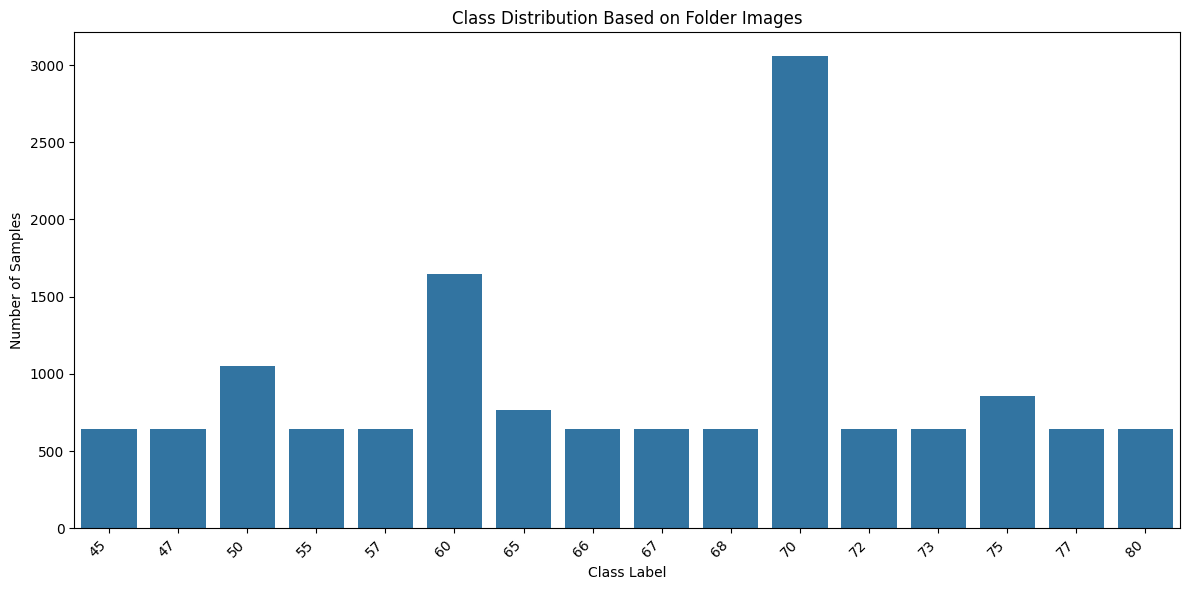

Updated Class Distribution:
45: 645 samples (4.45%)
47: 645 samples (4.45%)
50: 1054 samples (7.28%)
55: 645 samples (4.45%)
57: 645 samples (4.45%)
60: 1650 samples (11.39%)
65: 768 samples (5.30%)
66: 645 samples (4.45%)
67: 645 samples (4.45%)
68: 645 samples (4.45%)
70: 3059 samples (21.12%)
72: 645 samples (4.45%)
73: 645 samples (4.45%)
75: 857 samples (5.92%)
77: 645 samples (4.45%)
80: 645 samples (4.45%)


In [22]:
from collections import Counter

folder_counts = {}
for class_name in os.listdir(train_data_path):
    class_folder = os.path.join(train_data_path, class_name)
    if os.path.isdir(class_folder):
        count = len([f for f in os.listdir(class_folder) if f.endswith('.jpg')])
        folder_counts[class_name] = count

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(folder_counts.keys()), y=list(folder_counts.values()))
plt.title('Class Distribution Based on Folder Images')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print counts
print("Updated Class Distribution:")
total_imgs = sum(folder_counts.values())
for label, count in folder_counts.items():
    print(f"{label}: {count} samples ({(count/total_imgs)*100:.2f}%)")

### Data Class Weighting

Calculate class weighting on the dataframe

In [23]:
def get_class_counts_from_folders(data_dir):
    """
    Returns a dictionary with image counts per class folder.
    """
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        class_counts[class_name] = count
    return class_counts

def calculate_class_weights(class_counts):
    """
    Calculates class weights inversely proportional to class frequencies.
    """
    total_samples = sum(class_counts.values())
    num_classes = len(class_counts)
    class_weights = {}

    for class_name, count in class_counts.items():
        class_weights[class_name] = total_samples / (num_classes * count)

    print("Class weights:")
    for class_name, weight in class_weights.items():
        print(f"Class '{class_name}': {weight:.4f}")

    return class_weights

def map_weights_to_generator_indices(class_weights, generator_class_indices):
    """
    Maps class weights (based on class names) to generator indices used during model training.
    """
    index_weights = {}

    for class_name, weight in class_weights.items():
        if class_name in generator_class_indices:
            index = generator_class_indices[class_name]
            index_weights[index] = weight
        else:
            print(f"Warning: Class '{class_name}' not found in generator indices")

    for class_name, index in generator_class_indices.items():
        if index not in index_weights:
            print(f"Warning: No weight assigned for generator class '{class_name}' (index {index})")

    return index_weights


In [24]:
# Step 1: Get counts directly from folders
class_counts = get_class_counts_from_folders(train_data_path)

# Step 2: Compute weights
class_weights = calculate_class_weights(class_counts)

# Step 3: Get generator class indices
generator_class_indices = train_gen.class_indices
print("Generator class indices:", generator_class_indices)

# Step 4: Map weights to generator indices
index_weights = map_weights_to_generator_indices(class_weights, generator_class_indices)

print("-" * 30)

# Final weights to use in model.fit()
print("Mapped index weights:")
for idx, weight in sorted(index_weights.items()):
    print(f"Index {idx}: {weight:.4f}")

Class weights:
Class '45': 1.4034
Class '47': 1.4034
Class '50': 0.8588
Class '55': 1.4034
Class '57': 1.4034
Class '60': 0.5486
Class '65': 1.1786
Class '66': 1.4034
Class '67': 1.4034
Class '68': 1.4034
Class '70': 0.2959
Class '72': 1.4034
Class '73': 1.4034
Class '75': 1.0562
Class '77': 1.4034
Class '80': 1.4034
Generator class indices: {'45': 0, '47': 1, '50': 2, '55': 3, '57': 4, '60': 5, '65': 6, '66': 7, '67': 8, '68': 9, '70': 10, '72': 11, '73': 12, '75': 13, '77': 14, '80': 15}
------------------------------
Mapped index weights:
Index 0: 1.4034
Index 1: 1.4034
Index 2: 0.8588
Index 3: 1.4034
Index 4: 1.4034
Index 5: 0.5486
Index 6: 1.1786
Index 7: 1.4034
Index 8: 1.4034
Index 9: 1.4034
Index 10: 0.2959
Index 11: 1.4034
Index 12: 1.4034
Index 13: 1.0562
Index 14: 1.4034
Index 15: 1.4034


### Callback Functions for training monitoring and improvement

In [ ]:
class TerminateNaN(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        loss = logs.get('loss')
        if loss is not None:
            if np.isnan(loss) or np.isinf(loss):
                print(f"Invalid loss and terminated at loss {loss}; epoch: {epoch}")
                self.model.stop_training = True

terminate_nan = TerminateNaN()

# Callbacks for checking loss spike
class LossSpikeStopper(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get('val_loss')
        if val_loss is not None and val_loss > 5.0 and epoch > 10:
            print(f"\n[Early Stop] Validation loss spiked to {val_loss:.4f} at epoch {epoch}.")
            self.model.stop_training = True

loss_spike_stopper = LossSpikeStopper()

# Tensorboard test Track metrics, images, and more with TensorBoard:
tensorboard_cb = TensorBoard(log_dir='logs', histogram_freq=1)

In [25]:
# # Early stopping to prevent overfitting (validation loss stops improving)
# early_stopping_loss = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     min_delta=0.001,
#     patience=10,
#     verbose=1,
#     mode='min',
#     restore_best_weights=True
# )

# # Early stopping if validation accuracy doesn't improve
# early_stopping_accuracy = tf.keras.callbacks.EarlyStopping(
#     monitor='val_accuracy',
#     min_delta=0.001,
#     patience=10,
#     verbose=1,
#     mode='max',
#     restore_best_weights=True
# )

# early_stopping_mae = tf.keras.callbacks.EarlyStopping(
#     monitor='val_mean_absolute_error',  # CNN
#     patience=10,
#     verbose=1,
#     mode='min',
#     restore_best_weights=True
# )

# early_stopping_final_mae = tf.keras.callbacks.EarlyStopping(
#     monitor='val_final_age_MAE',  # Xception
#     patience=10,
#     verbose=1,
#     mode='min',
#     restore_best_weights=True
# )

## Evaluation Model

In [ ]:
def evaluate_model(history):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(18, 5))

    # 1. MAE Plot
    plt.subplot(1, 3, 1)
    if 'mean_absolute_error' in history.history:
        plt.plot(history.history['mean_absolute_error'], label='Train MAE')
    if 'val_mean_absolute_error' in history.history:
        plt.plot(history.history['val_mean_absolute_error'], label='Val MAE')
    if 'final_age_MAE' in history.history:
        plt.plot(history.history['final_age_MAE'], label='Train MAE (Xception)')
    if 'val_final_age_MAE' in history.history:
        plt.plot(history.history['val_final_age_MAE'], label='Val MAE (Xception)')
    plt.title('Mean Absolute Error (MAE)')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)

    # 2. RMSE Plot
    plt.subplot(1, 3, 2)
    if 'root_mean_squared_error' in history.history:
        plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
    if 'val_root_mean_squared_error' in history.history:
        plt.plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
    if 'final_age_RMSE' in history.history:
        plt.plot(history.history['final_age_RMSE'], label='Train RMSE (Xception)')
    if 'val_final_age_RMSE' in history.history:
        plt.plot(history.history['val_final_age_RMSE'], label='Val RMSE (Xception)')
    plt.title('Root Mean Squared Error (RMSE)')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)

    # 3. Loss Plot
    plt.subplot(1, 3, 3)
    if 'loss' in history.history:
        plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss (MSE)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


### CNN Model

In [ ]:
# CNN callbacks
cnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task3_cnn_model.h5',
    monitor='val_mean_absolute_error',  # or 'val_loss'
    verbose=1,
    save_best_only=True,
    mode='min',
    save_weights_only=False,
    save_freq='epoch'
)

cnn_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_mean_absolute_error',  # same as checkpoint
    factor=0.2,
    patience=4,
    verbose=1,
    mode='min',
    min_delta=0.001,
    cooldown=1,
    min_lr=1e-6
)

cnn_early_stop_plateau = tf.keras.callbacks.EarlyStopping(
    monitor='val_mean_absolute_error',
    patience=10,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

cnn_early_stop_overfit = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    min_delta=0.01,
    mode='min',
    verbose=1,
    restore_best_weights=True
)

cnn_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task3_cnn_training_history.csv',
    separator=',',
    append=True
)

# List of callbacks to use
cnn_callbacks = [
    terminate_nan,
    cnn_checkpoint,
    cnn_reduce_lr,
    cnn_early_stop_plateau,
    cnn_early_stop_overfit,
    cnn_csv_logger,
    loss_spike_stopper,
    tensorboard_cb
]

In [31]:
# For Task 3: Age Prediction (Regression)
cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
   # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Fourth block
    layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # Add dropout to prevent overfitting
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Regression output - single neuron with linear activation
    layers.Dense(1)  # No activation function for regression (linear by default)
])

# Compile the model with regression metrics
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.MeanSquaredError(),  # MSE for regression
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mean_absolute_error"),  # MAE
        tf.keras.metrics.RootMeanSquaredError(name="root_mean_squared_error")  # RMSE
    ]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 26,149,313 (99.75 MB)

 Trainable params: 26,147,073 (99.74 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [ ]:
cnn_history = cnn_model.fit(
    train_gen,
    batch_size = 16,
    validation_data = valid_gen,
    epochs=150,
    verbose=1,
    class_weight=index_weights,
        callbacks = cnn_callbacks 
)

In [ ]:
cnn_val_acc = evaluate_model(cnn_history)

## Xception Model

In [ ]:
# Xception model callbacks
xception_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task3_xception_model.h5',
    monitor='val_final_age_MAE',
    verbose=1,
    save_best_only=True,
    mode='min',
    save_weights_only=False,
    save_freq='epoch'
)

xception_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_final_age_MAE',
    factor=0.2,
    patience=4,
    verbose=1,
    mode='min',
    min_delta=0.001,
    cooldown=1,
    min_lr=1e-6
)

xception_early_stop_overfit = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    min_delta=0.01,
    mode='min',
    verbose=1,
    restore_best_weights=True
)

xception_early_stop_plateau = tf.keras.callbacks.EarlyStopping(
    monitor='val_final_age_MAE',
    patience=10,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

xception_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task3_xception_training_history.csv',
    separator=',',
    append=True
)

# List of callbacks to use
xception_callbacks = [
    terminate_nan,
    xception_checkpoint,
    xception_reduce_lr,
    xception_early_stop,
    xception_csv_logger,
    loss_spike_stopper,
    tensorboard_cb
]


In [34]:
# Input with reduced size for lower GPU load
input_tensor = Input(shape=(224, 224, 3), name="input_image")

# Base Xception model (from scratch, no pretraining)
base_model = Xception(
    weights=None,
    include_top=False,
    input_tensor=input_tensor
)

base_model.trainable = True

# Feature extractor output
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Multi-head function
def age_head(name):
    h = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    h = layers.Dropout(0.3)(h)
    h = layers.Dense(1, name=name,activation='relu')(h)
    return h

# Branches for different age stages
young_output = age_head('young_output')
medium_output = age_head('medium_output')
mature_output = age_head('mature_output')

# Final fusion output
combined = layers.Concatenate(name='combined_heads')([young_output, medium_output, mature_output])
fused = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(combined)
final_output = layers.Dense(1, name='final_age', activation='relu')(fused)

# Full model definition
xception_model = Model(
    inputs=input_tensor,
    outputs=[final_output, young_output, medium_output, mature_output],
    name="Xception_Age_Regression"
)

# Compile model
xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss={
        'final_age': tf.keras.losses.MeanSquaredError(),
        'young_output': tf.keras.losses.MeanSquaredError(),
        'medium_output': tf.keras.losses.MeanSquaredError(),
        'mature_output': tf.keras.losses.MeanSquaredError()
    },
    loss_weights={
        'final_age': 1.0,
        'young_output': 0.25,
        'medium_output': 0.25,
        'mature_output': 0.25
    },
    metrics={
        'final_age': [
            tf.keras.metrics.MeanAbsoluteError(name='MAE'),
            tf.keras.metrics.RootMeanSquaredError(name='RMSE')
        ]
    }
)

xception_model.summary()

Model: "Xception_Age_Regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 111, 111, 32)      │             864 │ input_image[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_bn               │ (None, 111, 111, 32)      │             128 │ block1_conv1[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_act (Activation) │ (None, 111, 111, 32)      │               0 │ block1_conv1_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 109, 109, 64)      │          18,432 │ block1_conv1_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_bn               │ (None, 109, 109, 64)      │             256 │ block1_conv2[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_act (Activation) │ (None, 109, 109, 64)      │               0 │ block1_conv2_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1               │ (None, 109, 109, 128)     │           8,768 │ block1_conv2_act[0][0]     │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1_bn            │ (None, 109, 109, 128)     │             512 │ block2_sepconv1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_act           │ (None, 109, 109, 128)     │               0 │ block2_sepconv1_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2               │ (None, 109, 109, 128)     │          17,536 │ block2_sepconv2_act[0][0]  │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_bn            │ (None, 109, 109, 128)     │             512 │ block2_sepconv2[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_211 (Conv2D)           │ (None, 55, 55, 128)       │           8,192 │ block1_conv2_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 55, 55, 128)       │               

 Total params: 23,752,044 (90.61 MB)

 Trainable params: 23,695,468 (90.39 MB)

 Non-trainable params: 56,576 (221.00 KB)

In [ ]:
xception_history = xception_model.fit(
    train_gen,
    batch_size = 16,
    validation_data = valid_gen,
    epochs=150,
    verbose=1,
    class_weight=index_weights,
        callbacks = xception_callbacks
)

In [ ]:
xception_val_acc = evaluate_model(xception_history)

## Check best model

In [ ]:
def find_best_model(histories):
    """
    Finds the best model based on the lowest MAE for the appropriate model.
    """
    best_mae = float('inf')
    best_model = None
    model_metrics = {
        "Xception": "val_final_age_MAE",
        "CNN": "val_mean_absolute_error"
    }

    for name, hist in histories.items():
        model_type = "Xception" if "Xception" in name else "CNN"
        val_mae = min(hist.history.get(model_metrics[model_type], [float('inf')]))

        print(f"{name}: Best Val MAE = {val_mae:.4f}")

        if val_mae < best_mae:
            best_mae = val_mae
            best_model = name

    print(f"\nBest model: {best_model} with MAE = {best_mae:.4f}")
    return best_model

find_best_model(histories)

In [ ]:
def evaluate_models(histories, metrics_to_check=None):
    import matplotlib.pyplot as plt

    # If no specific metrics provided, collect all available validation metrics
    if metrics_to_check is None:
        metrics_to_check = set()
        for hist in histories.values():
            for metric in hist.history.keys():
                if metric.startswith('val_'):
                    metrics_to_check.add(metric)

    results = {}
    summary = {}

    print("=" * 90)
    print(f"{'Model':<25} | {'Metric':<30} | {'Best Value':<15} | {'Epoch':<10}")
    print("=" * 90)

    for model_name, history in histories.items():
        model_results = {}

        for metric in metrics_to_check:
            if metric in history.history:
                values = history.history[metric]

                # Regression metrics should be minimized
                is_maximize = False

                best_value = min(values)
                best_epoch = values.index(best_value) + 1

                model_results[metric] = {
                    'best_value': best_value,
                    'best_epoch': best_epoch,
                    'is_maximize': is_maximize
                }

                print(f"{model_name:<25} | {metric:<30} | {best_value:.4f}       | {best_epoch:<10}")

                if metric not in summary or best_value < summary[metric]['best_value']:
                    summary[metric] = {
                        'best_model': model_name,
                        'best_value': best_value
                    }

        results[model_name] = model_results

    # Summary
    print("\n" + "=" * 50)
    print("BEST MODEL FOR EACH METRIC:")
    print("=" * 50)
    for metric, data in summary.items():
        print(f"{metric:<30}: {data['best_model']} (Value: {data['best_value']:.4f})")

    # Visualization
    plt.figure(figsize=(16, 10))
    viz_metrics = [m for m in metrics_to_check if m.startswith('val_')]

    for i, metric in enumerate(viz_metrics[:4]):
        plt.subplot(2, 2, i + 1)
        for model_name, history in histories.items():
            if metric in history.history:
                plt.plot(history.history[metric], label=f"{model_name}")
                train_metric = metric.replace('val_', '')
                if train_metric in history.history:
                    plt.plot(history.history[train_metric], linestyle='--', alpha=0.6, label=f"{model_name} (train)")
        plt.title(metric.replace('val_', 'Validation '))
        plt.xlabel("Epoch")
        plt.ylabel("Value")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

    plt.tight_layout()
    plt.show()

    return summary

best_models = evaluate_models(histories)